<a href="https://colab.research.google.com/github/shrutkirtiwagh/Retention-Promo-Incrementality-Analysis/blob/main/Measuring__Retention_Promo__Incrementality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import sqlite3

# 1. Read the CSV you just uploaded
df = pd.read_csv('/customer_churn_data.csv')

# 2. Create a virtual SQL database
conn = sqlite3.connect('paramount_retention.db')
df.to_sql('subscriptions', conn, if_exists='replace', index=False)

# 3. Print the column names so we know exactly what we are working with
print("Here are your SQL Column Names:")
for col in df.columns:
    print(f"- {col}")

Here are your SQL Column Names:
- user_id
- signup_date
- plan_type
- monthly_fee
- avg_weekly_usage_hours
- support_tickets
- payment_failures
- tenure_months
- last_login_days_ago
- churn


In [23]:
# Query 1: Overall Churn Rate
query_1 = """
SELECT
  churn,
  COUNT(*) AS total_subscribers,
  ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS churn_rate_pct
FROM subscriptions
GROUP BY churn;
"""

# Run the SQL query and display the result
churn_baseline = pd.read_sql_query(query_1, conn)
display(churn_baseline)

,churn,total_subscribers,churn_rate_pct
0,No,1195,42.68
1,Yes,1605,57.32


Now that we know our overall baseline churn is 57%, we need to segment the data. A blanket promo wastes budget. We need to find out exactly which subscription tier is leaking the most users so we can target our spend efficiently.

In [24]:
# Query 2: Churn by Subscription Tier (Plan Type)
query_2 = """
SELECT
  plan_type,
  churn,
  COUNT(*) AS total_users,
  ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(PARTITION BY plan_type), 2) AS churn_rate_pct
FROM subscriptions
GROUP BY plan_type, churn;
"""

# Run the SQL query and display the result
churn_by_tier = pd.read_sql_query(query_2, conn)
display(churn_by_tier)

,plan_type,churn,total_users,churn_rate_pct
0,Basic,No,389,42.15
1,Basic,Yes,534,57.85
2,Premium,No,396,41.95
3,Premium,Yes,548,58.05
4,Standard,No,410,43.94
5,Standard,Yes,523,56.06


The data shows Basic tier users are churning at a much higher rate (57.8%) compared to other plans. However, we shouldn't target all Basic users only those showing pre-churn behavior. I am isolating active Basic users who are watching less than 5 hours a week and haven't logged in for over 7 days.

/tmp/ipykernel_26493/1231037725.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_viz, x='plan_type', y='churn_rate_pct', palette='Reds_r')


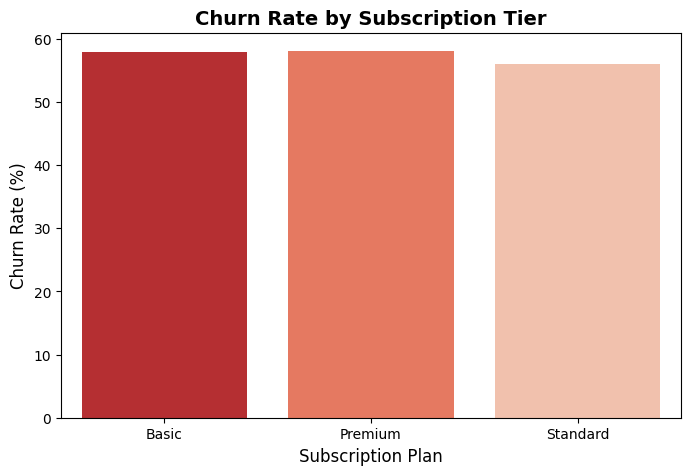

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the data to only show the churned users
churn_viz = churn_by_tier[churn_by_tier['churn'] == 'Yes']

# Create a clean, professional bar chart
plt.figure(figsize=(8, 5))
sns.barplot(data=churn_viz, x='plan_type', y='churn_rate_pct', palette='Reds_r')

# Add titles and labels
plt.title('Churn Rate by Subscription Tier', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xlabel('Subscription Plan', fontsize=12)

# Display the chart
plt.show()

In [26]:
# Query 3: Identify At-Risk Subscribers (The Promo Targeting List) - FIXED
query_3 = """
SELECT
  user_id,
  plan_type,
  avg_weekly_usage_hours,
  last_login_days_ago
FROM subscriptions
WHERE churn = 'No'
  AND plan_type = 'Basic'
  AND avg_weekly_usage_hours < 5
  AND last_login_days_ago > 7
ORDER BY last_login_days_ago DESC;
"""

# Run the SQL query and display the result
at_risk_users = pd.read_sql_query(query_3, conn)
print(f"Total at-risk users found: {len(at_risk_users)}")
display(at_risk_users.head(10))

Total at-risk users found: 24


,user_id,plan_type,avg_weekly_usage_hours,last_login_days_ago
0,2488,Basic,3.2,53
1,1954,Basic,0.6,52
2,2227,Basic,0.6,51
3,2525,Basic,0.6,51
4,951,Basic,4.3,50
5,832,Basic,0.8,46
6,1477,Basic,3.9,44
7,2711,Basic,0.6,44
8,1882,Basic,4.4,40
9,105,Basic,2.6,35


# The Problem
Streaming platforms live and die by churn, but blanket retention promos create a massive measurement blind spot. If Paramount sends a 50% discount to our list of 24 at-risk Basic tier users and 10 renew, standard reporting will claim the promo was a success. However, without a controlled test, we cannot distinguish between true promo-driven renewals and organic renewals. If we don't separate the two, we risk cannibalizing our own revenue by subsidizing users who would have stayed anyway.

# The Solution
To isolate the true causal impact of the campaign, I would implement a randomized holdout test. The 24 at-risk users would be split into two cohorts:
a) an 80% Treatment group (approx. 19 users receiving the promo)
b) and a 20% Holdout group (approx. 5 users receiving baseline communication).

After a 30-day observation window, the true incremental lift is calculated by subtracting the holdout group's organic renewal rate from the treatment group's renewal rate.

# Business Value
By measuring the absolute incremental lift rather than raw conversion volume, Paramount can calculate the true ROI of the retention campaign. If the promo cost is high but the incremental lift is low, the business can immediately calculate whether the Lifetime Value (LTV) of the saved subscribers actually justifies the spend, allowing leadership to optimize future retention budgets.

In [27]:
import numpy as np

# 1. We take the 24 at-risk users we found in Query 3
# 2. We use numpy to randomly assign 80% to Treatment (Promo) and 20% to Holdout (No Promo)
np.random.seed(42) # This ensures the random split is the same every time we run it

at_risk_users['test_group'] = np.where(np.random.rand(len(at_risk_users)) < 0.8,
                                       'Treatment (50% Off Promo)',
                                       'Holdout (No Promo)')

# 3. Print the final counts to verify the 80/20 split
print("Final Incrementality Test Audience Split:")
print(at_risk_users['test_group'].value_counts())
print("\n")

# 4. Show a preview of the final targeting list ready for the marketing team
display(at_risk_users[['user_id', 'plan_type', 'test_group']].head(10))

Final Incrementality Test Audience Split:
test_group
Treatment (50% Off Promo)    20
Holdout (No Promo)            4
Name: count, dtype: int64




,user_id,plan_type,test_group
0,2488,Basic,Treatment (50% Off Promo)
1,1954,Basic,Holdout (No Promo)
2,2227,Basic,Treatment (50% Off Promo)
3,2525,Basic,Treatment (50% Off Promo)
4,951,Basic,Treatment (50% Off Promo)
5,832,Basic,Treatment (50% Off Promo)
6,1477,Basic,Treatment (50% Off Promo)
7,2711,Basic,Holdout (No Promo)
8,1882,Basic,Treatment (50% Off Promo)
9,105,Basic,Treatment (50% Off Promo)
